# TP2 — Algoritmos de Predicción y Evaluación de Modelos
### Inteligencia Artificial y Aprendizaje Automático I · 2026
### Dataset: transacciones inmobiliarias — Prefectura de Tokio (MLIT)

Segunda etapa del proyecto integrador. Partimos del dataset limpio del TP1
(`tokyo_tp1_procesado.csv`, toda la Prefectura de Tokio) y retomamos su pregunta de predicción:

> **¿Podemos estimar el `Total transaction value` (¥) a partir de las características del inmueble, su
> ubicación (incluido el **ward**) y su entorno urbano?**

Implementamos y comparamos **≥3 regresores** con marco controlado (baseline + hold-out 80/20 + CV
5-fold) y evaluación multimétrica (RMSE, MAE, R², R² ajustado, MAPE).

## 0. Setup

In [9]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

try:
    from xgboost import XGBRegressor
    HAY_XGB = True
except ImportError:
    from sklearn.ensemble import GradientBoostingRegressor
    HAY_XGB = False
    print("XGBoost no disponible: se usará GradientBoostingRegressor como tercer modelo.")

# --- Detección de GPU (NVIDIA) para XGBoost -------------------------------------------------
# XGBoost puede entrenar en GPU con device="cuda". El Random Forest de scikit-learn NO tiene
# soporte GPU (es CPU-only), por eso se optimiza vía hiperparámetros más abajo.
USAR_GPU = False
if HAY_XGB:
    try:
        import subprocess
        subprocess.run(["nvidia-smi"], capture_output=True, check=True, timeout=10)
        USAR_GPU = True
        print("GPU NVIDIA detectada: XGBoost entrenará en GPU (device='cuda').")
    except Exception:
        print("Sin GPU NVIDIA disponible: XGBoost entrenará en CPU.")

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 40)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = "outputs/processed/tokyo_tp1_procesado.csv"   # salida del TP1
MODEL_DIR = "outputs/models"
os.makedirs(MODEL_DIR, exist_ok=True)

GPU NVIDIA detectada: XGBoost entrenará en GPU (device='cuda').


### A.3 Features: exclusiones clave

| Excluida | Motivo |
|---|---|
| `precio_suelo_m2` | Dato original del MLIT (`Land : Price per m2`), sólo presente en *Land Only* y derivado del valor del suelo → *leakage*. |
| `precio_por_m2` | Variable derivada en el TP1 como precio/superficie → **leakage directo del target**. |
| `Building : Structure`, `estructura_principal` | Son el target del TP3. |
| `District`, `Nearest station : Name` (crudas) | Se usan sus versiones agrupadas del TP1. |

> **No confundir** `precio_suelo_m2` (dato original del MLIT, sólo *Land Only*) con `precio_por_m2`
> (derivada en el TP1 para todas las filas). Los nombres son parecidos pero designan cosas distintas;
> ambas se excluyen acá, por motivos diferentes.

**`ward` NO se excluye:** es la feature de ubicación principal (One-Hot) y, sobre toda la prefectura,
se espera que sea uno de los predictores de precio más fuertes. Se incluyen además las numéricas
(superficie, frente, `distancia_estacion_min`, antigüedad, ratios), el resto de categóricas y los flags.

## 1. Carga del dataset procesado del TP1

In [10]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head(3)


Shape: (343995, 42)


,ward,District,district_agrupado,Nearest station : Name,estacion_agrupada,Type,Area,City planning,Land : Shape,Frontage road : Direction,Frontage road : Type,anio_operacion,trimestre_operacion,anio_construccion,antiguedad,antes_de_guerra,antiguedad_inconsistente,area_terreno_m2,area_terreno_capada,area_construida_m2,...,ratio_construido_sospechoso,Frontage,Frontage road : Width,Building coverage ratio,Floor area ratio,distancia_estacion_min,distancia_estacion_nula,uso_house,uso_office,uso_shop,uso_warehouse,uso_parking_lot,uso_housing_complex,sin_edificio,tiene_nota_transaccion,precio_suelo_m2,precio_por_m2,Total transaction value,Building : Structure,estructura_principal
0,Chiyoda,Iidabashi,Otros,Iidabashi,Otros,Residential Land(Land and Building),Commercial Area,Commerical,Rectangular Shaped,Northeast,Tokyo Metropolitan Road,2025,2,1954.0,71.0,0,0,50,False,75.0,...,0,3.5,27.0,80.0,700.0,0.0,0,1,0,1,0,0,0,0,0,NaN,6.800000e+06,340000000,W,W
1,Chiyoda,Iidabashi,Otros,Iidabashi,Otros,Residential Land(Land and Building),Commercial Area,Commerical,Irregular Shaped,Northwest,Ward Road,2024,3,2024.0,0.0,0,0,55,False,400.0,...,0,10.0,8.0,80.0,700.0,4.0,0,0,1,1,0,0,0,0,0,NaN,1.509091e+07,830000000,S,S
2,Chiyoda,Iidabashi,Otros,Iidabashi,Otros,Residential Land(Land and Building),Commercial Area,Commerical,Rectangular Shaped,South,Ward Road,2023,4,1970.0,53.0,0,0,95,False,320.0,...,0,7.5,10.6,80.0,500.0,1.0,0,1,1,0,1,0,0,0,0,NaN,1.894737e+06,180000000,RC,RC


## 2. Definición de `X`, `y` y grupos de columnas
Los nulos remanentes del TP1 son mayormente **estructurales** (ej. `antiguedad` es nula en `Land Only`).
Se resuelven **dentro del pipeline** con imputación, nunca antes del split, para no filtrar información
del test al train.

In [11]:
TARGET = "Total transaction value"

# Excluidas por las razones de A.3. 'ward' NO se excluye: es la feature de ubicación principal.
# 'District'/'Nearest station : Name' crudas se excluyen (se usan sus versiones agrupadas del TP1).
EXCLUIDAS = ["precio_suelo_m2", "precio_por_m2",
             "Building : Structure", "estructura_principal",
             "District", "Nearest station : Name", TARGET]

y = np.log1p(df[TARGET].values)         # entrenamos en escala log1p
y_real = df[TARGET].values              # guardamos la escala original para reportar

X = df.drop(columns=[c for c in EXCLUIDAS if c in df.columns]).copy()

# Convertir flags booleanos a int por prolijidad
for c in X.select_dtypes(include="bool").columns:
    X[c] = X[c].astype(int)

# Grupos de columnas. 'ward' entra como categórica (One-Hot dentro del pipeline).
cols_categoricas = [c for c in ["ward", "district_agrupado", "estacion_agrupada", "Type", "Area",
                                "City planning", "Land : Shape", "Frontage road : Direction",
                                "Frontage road : Type"] if c in X.columns]
cols_numericas = [c for c in X.columns if c not in cols_categoricas]

print(f"Total features: {X.shape[1]}  |  numéricas: {len(cols_numericas)}  |  categóricas: {len(cols_categoricas)}")
print("\nNuméricas:", cols_numericas)
print("\nCategóricas:", cols_categoricas)

Total features: 35  |  numéricas: 26  |  categóricas: 9

Numéricas: ['anio_operacion', 'trimestre_operacion', 'anio_construccion', 'antiguedad', 'antes_de_guerra', 'antiguedad_inconsistente', 'area_terreno_m2', 'area_terreno_capada', 'area_construida_m2', 'area_construida_capada', 'ratio_construido', 'ratio_construido_sospechoso', 'Frontage', 'Frontage road : Width', 'Building coverage ratio', 'Floor area ratio', 'distancia_estacion_min', 'distancia_estacion_nula', 'uso_house', 'uso_office', 'uso_shop', 'uso_warehouse', 'uso_parking_lot', 'uso_housing_complex', 'sin_edificio', 'tiene_nota_transaccion']

Categóricas: ['ward', 'district_agrupado', 'estacion_agrupada', 'Type', 'Area', 'City planning', 'Land : Shape', 'Frontage road : Direction', 'Frontage road : Type']


## 3. Partición train/test

In [12]:
X_train, X_test, y_train, y_test, yreal_train, yreal_test = train_test_split(
    X, y, y_real, test_size=0.20, random_state=RANDOM_STATE)

print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (275196, 35)  Test: (68799, 35)


## 4. Preprocesamiento (ColumnTransformer)
- **Numéricas:** imputación por mediana (robusta a outliers) + `StandardScaler` (solo afecta al lineal;
  indiferente para los árboles, se deja en el pipeline común).
- **Categóricas:** imputación por moda + `OneHotEncoder` (viable porque el TP1 ya agrupó las raras).

In [13]:
preproc_numerico = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preproc_categorico = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocesador = ColumnTransformer([
    ("num", preproc_numerico, cols_numericas),
    ("cat", preproc_categorico, cols_categoricas),
])


## 5. Definición de los modelos
Elegidos por la naturaleza tabular y heterogénea del dataset:

| Modelo | Rol | Por qué acá |
|---|---|---|
| **Regresión Lineal Múltiple** | Baseline | Interpretable; mide cuánto aporta la complejidad. |
| **Random Forest Regressor** | Ensamble | Captura no linealidades e interacciones; robusto a outliers y escala. |
| **XGBoost Regressor** | Boosting | Suele dar el menor error en datos tabulares; robusto a la cola de precios. |

Se añade además una **referencia trivial** (`DummyRegressor`, predice siempre la mediana). El enunciado
pide un modelo de línea base y la Regresión Lineal cumple ese rol, pero la referencia trivial aporta
algo distinto: mide cuánto se gana por el solo hecho de usar variables explicativas. Es el piso absoluto
contra el que se contrasta cualquier mejora.

> **Nota de costo computacional.** Con ~275k filas de entrenamiento y ~150 columnas tras el One-Hot, los
> ensambles sin restricciones son inviables en una máquina de escritorio. Decisiones tomadas:
> - **Random Forest acotado** (`max_depth=20`, `min_samples_leaf=5`, `max_features="sqrt"`): scikit-learn
>   **no tiene soporte GPU**, así que el control de costo es vía hiperparámetros. La pérdida de
>   performance es mínima y evita además el sobreajuste de árboles sin límite.
> - **XGBoost con `tree_method="hist"` y `device="cuda"`** si hay GPU NVIDIA disponible (se detecta
>   automáticamente en el setup).
> - **`n_jobs=1` en las validaciones cruzadas**, porque los modelos ya paralelizan internamente;
>   paralelizar en ambos niveles genera sobresuscripción de threads y ralentiza todo.

In [14]:
if HAY_XGB:
    tercer_modelo = XGBRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        tree_method="hist",                             # histogram-based: mucho más rápido
        device="cuda" if USAR_GPU else "cpu",           # GPU si está disponible
        random_state=RANDOM_STATE, n_jobs=-1)
    nombre_tercero = "XGBoost"
else:
    tercer_modelo = GradientBoostingRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE)
    nombre_tercero = "GradientBoosting"

modelos = {
    "Regresión Lineal": LinearRegression(),
    # Random Forest ACOTADO: con ~275k filas de train y ~150 columnas tras el One-Hot,
    # max_depth=None construye árboles enormes y el entrenamiento se vuelve inviable.
    # Limitar profundidad y hojas recorta drásticamente el costo con pérdida mínima de performance.
    "Random Forest": RandomForestRegressor(
        n_estimators=200,          # antes 300
        max_depth=20,              # antes None -> árboles sin límite
        min_samples_leaf=5,        # antes 2 -> hojas casi puras, muy costosas
        max_features="sqrt",       # menos features evaluadas por split
        random_state=RANDOM_STATE, n_jobs=-1),
    nombre_tercero: tercer_modelo,
}
print("Modelos a entrenar:", list(modelos.keys()))

Modelos a entrenar: ['Regresión Lineal', 'Random Forest', 'XGBoost']


## 6. Funciones de evaluación
Aunque el modelo predice en `log1p`, calculamos todas las métricas en **escala original (¥)** con
`expm1`, que es la interpretable.

In [15]:
def metricas_regresion(y_true_real, y_pred_real, n_features):
    """Calcula RMSE, MAE, R², R² ajustado y MAPE en la escala original (¥)."""
    mse = mean_squared_error(y_true_real, y_pred_real)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true_real, y_pred_real)
    r2 = r2_score(y_true_real, y_pred_real)
    n = len(y_true_real)
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    mape = np.mean(np.abs((y_true_real - y_pred_real) / y_true_real)) * 100
    return {"MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2, "R2_adj": r2_adj, "MAPE": mape}


def a_escala_real(y_log):
    """Deshace log1p para volver a ¥."""
    return np.expm1(y_log)


# ---------------------------------------------------------------------------------------------
# REFERENCIA TRIVIAL — predecir siempre la mediana del target.
# La Regresión Lineal es el baseline "modelo" que pide el enunciado, pero conviene además una
# referencia mínima sin ninguna capacidad predictiva: cuantifica cuánto aporta realmente el
# hecho de usar las variables explicativas. Un modelo que no supere claramente esta referencia
# no está aprendiendo nada del dominio.
# ---------------------------------------------------------------------------------------------
dummy = DummyRegressor(strategy="median")
dummy.fit(X_train, y_train)
pred_dummy = a_escala_real(dummy.predict(X_test))
m_dummy = metricas_regresion(yreal_test, pred_dummy, 1)
print(f"[Referencia trivial - mediana]  RMSE = ¥{m_dummy['RMSE']:,.0f}  |  "
      f"MAE = ¥{m_dummy['MAE']:,.0f}  |  R² = {m_dummy['R2']:.3f}")
print("Todo modelo posterior debe mejorar claramente estos valores para justificarse.")

[Referencia trivial - mediana]  RMSE = ¥729,601,638  |  MAE = ¥67,094,539  |  R² = -0.005
Todo modelo posterior debe mejorar claramente estos valores para justificarse.


## 7. Entrenamiento, CV y evaluación
Por modelo: `Pipeline` (preproc + modelo) → CV 5-fold sobre train (R² en log) → fit en train →
métricas en ¥ para train y test.

In [16]:
kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

resultados = []
pipelines_entrenados = {}
predicciones_test = {}

for nombre, modelo in modelos.items():
    pipe = Pipeline([("prep", preprocesador), ("model", modelo)])

    # Validación cruzada sobre train (R² en escala log).
    # n_jobs=1 acá A PROPÓSITO: los modelos ya paralelizan internamente con n_jobs=-1.
    # Paralelizar en ambos niveles genera sobresuscripción de threads (más procesos que núcleos),
    # lo que ralentiza el entrenamiento y satura la máquina.
    cv_r2 = cross_val_score(pipe, X_train, y_train, cv=kfold, scoring="r2", n_jobs=1)

    # Entrenamiento final
    pipe.fit(X_train, y_train)
    pipelines_entrenados[nombre] = pipe

    # Predicciones en escala log (donde se entrena) y en escala ¥ (para reportar)
    predlog_train = pipe.predict(X_train)
    predlog_test = pipe.predict(X_test)
    pred_train = a_escala_real(predlog_train)
    pred_test = a_escala_real(predlog_test)
    predicciones_test[nombre] = pred_test

    n_feat = pipe.named_steps["prep"].transform(X_train).shape[1]
    m_train = metricas_regresion(yreal_train, pred_train, n_feat)
    m_test = metricas_regresion(yreal_test, pred_test, n_feat)

    # R² en escala log: es la escala donde el modelo optimiza -> comparación justa entre modelos
    r2log_train = r2_score(y_train, predlog_train)
    r2log_test = r2_score(y_test, predlog_test)

    resultados.append({
        "Modelo": nombre,
        "CV_R2_log": cv_r2.mean(), "CV_R2_std": cv_r2.std(),
        "R2log_train": r2log_train, "R2log_test": r2log_test,
        "R2_train": m_train["R2"], "R2_test": m_test["R2"], "R2_adj_test": m_test["R2_adj"],
        "RMSE_train": m_train["RMSE"], "RMSE_test": m_test["RMSE"],
        "MAE_train": m_train["MAE"], "MAE_test": m_test["MAE"],
        "MAPE_test": m_test["MAPE"],
    })
    print(f"{nombre:20s}  CV R²(log)={cv_r2.mean():.3f}±{cv_r2.std():.3f}  "
          f"R²(log)test={r2log_test:.3f}  R²(¥)test={m_test['R2']:.3f}  RMSEtest=¥{m_test['RMSE']:,.0f}")

df_resultados = pd.DataFrame(resultados)

Regresión Lineal      CV R²(log)=0.728±0.003  R²(log)test=0.724  R²(¥)test=0.100  RMSEtest=¥690,425,179
Random Forest         CV R²(log)=0.707±0.003  R²(log)test=0.705  R²(¥)test=0.077  RMSEtest=¥699,123,745
XGBoost               CV R²(log)=0.850±0.002  R²(log)test=0.848  R²(¥)test=0.267  RMSEtest=¥622,950,151


## 8. Tabla comparativa consolidada
Métricas en **train** y **test** para los tres modelos.

> **Dos escalas de R².** El modelo optimiza en `log1p`, pero RMSE/MAE se reportan en ¥. Por eso mostramos
> `R2log_test` (escala de entrenamiento → **comparación justa** entre modelos) y `R2_test` en ¥ (más
> exigente, puede ser bajo o negativo en el baseline: `expm1` amplifica el error en la cola de miles de
> millones). Ese contraste es en sí un hallazgo (ver cuestionario, pregunta 3).

In [17]:
tabla = df_resultados.copy()
tabla_fmt = tabla.copy()
for c in ["RMSE_train", "RMSE_test", "MAE_train", "MAE_test"]:
    tabla_fmt[c] = tabla_fmt[c].apply(lambda v: f"¥{v:,.0f}")
for c in ["CV_R2_log", "CV_R2_std", "R2log_train", "R2log_test", "R2_train", "R2_test", "R2_adj_test"]:
    tabla_fmt[c] = tabla_fmt[c].round(3)
tabla_fmt["MAPE_test"] = tabla_fmt["MAPE_test"].round(1).astype(str) + "%"
tabla_fmt.set_index("Modelo")


,CV_R2_log,CV_R2_std,R2log_train,R2log_test,R2_train,R2_test,R2_adj_test,RMSE_train,RMSE_test,MAE_train,MAE_test,MAPE_test
Modelo,,,,,,,,,,,,
Regresión Lineal,0.728,0.003,0.728,0.724,0.133,0.100,0.096,"¥371,459,604","¥690,425,179","¥46,490,175","¥47,182,148",164.3%
Random Forest,0.707,0.003,0.729,0.705,0.256,0.077,0.073,"¥343,988,369","¥699,123,745","¥40,942,656","¥43,225,680",195.9%
XGBoost,0.850,0.002,0.864,0.848,0.603,0.267,0.264,"¥251,363,557","¥622,950,151","¥26,994,770","¥29,490,866",140.1%


## 9. Visualizaciones comparativas

### 9.1 Métricas por modelo (barras)

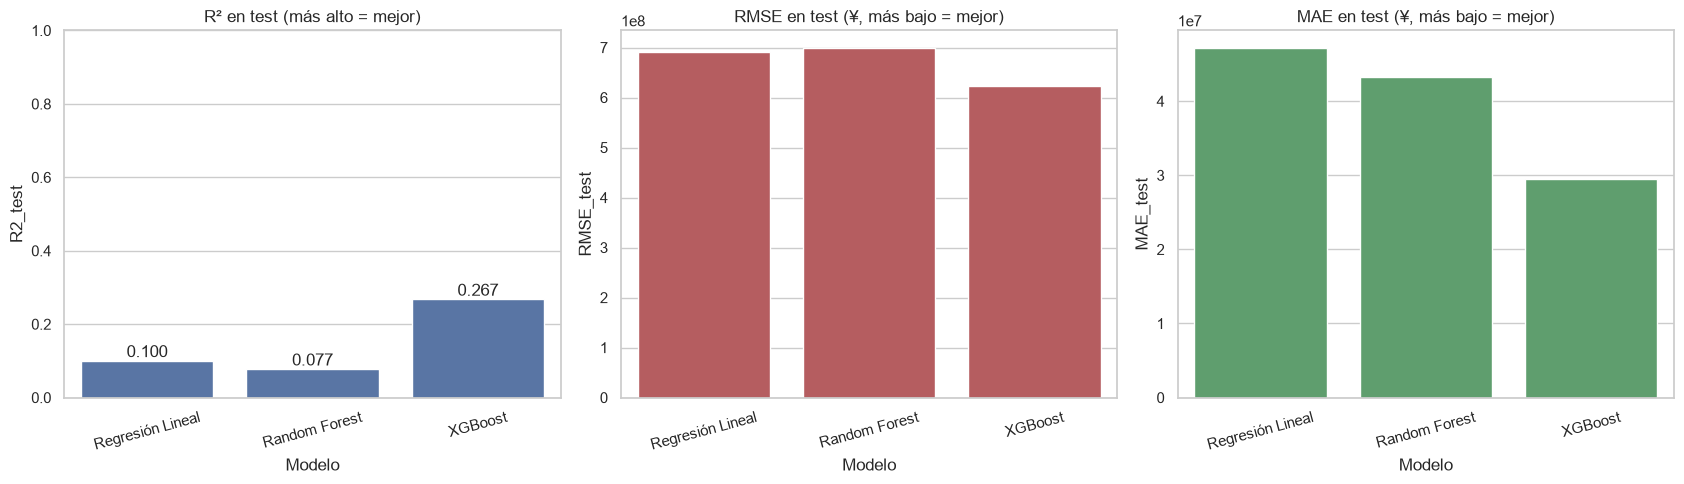

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.barplot(data=df_resultados, x="Modelo", y="R2_test", ax=axes[0], color="#4C72B0")
axes[0].set_title("R² en test (más alto = mejor)")
axes[0].set_ylim(0, 1)
for i, v in enumerate(df_resultados["R2_test"]):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha="center")

sns.barplot(data=df_resultados, x="Modelo", y="RMSE_test", ax=axes[1], color="#C44E52")
axes[1].set_title("RMSE en test (¥, más bajo = mejor)")

sns.barplot(data=df_resultados, x="Modelo", y="MAE_test", ax=axes[2], color="#55A868")
axes[2].set_title("MAE en test (¥, más bajo = mejor)")

for ax in axes:
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()


### 9.2 Comparación train vs. test (diagnóstico de overfitting)

Usamos el **R² en escala log** (la escala de entrenamiento) para que el diagnóstico de sobreajuste sea
justo: una brecha grande entre train y test señala varianza alta (overfitting).


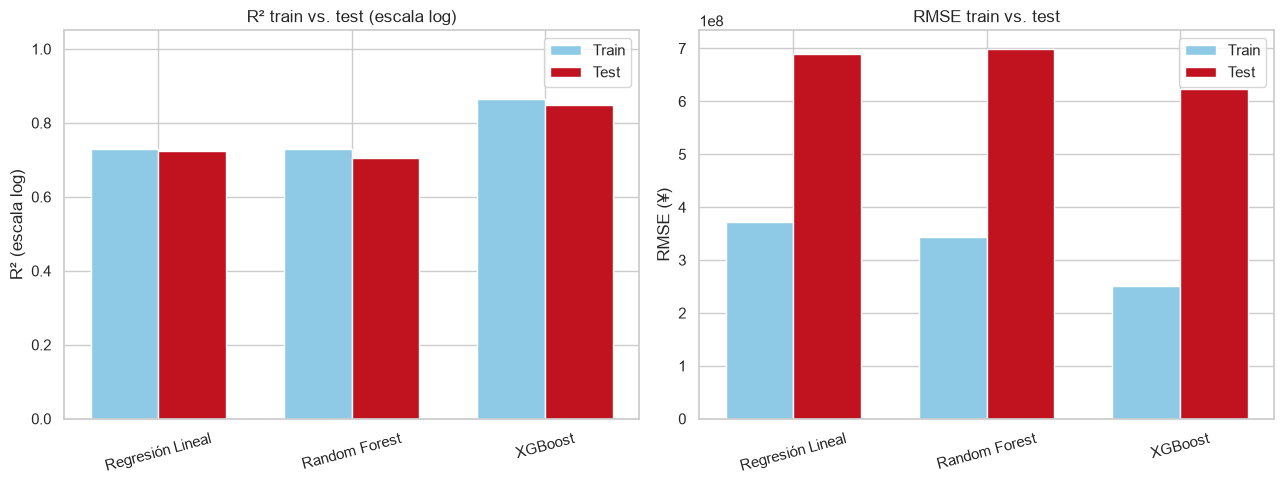

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(len(df_resultados))
ancho = 0.35
axes[0].bar(x - ancho/2, df_resultados["R2log_train"], ancho, label="Train", color="#8ecae6")
axes[0].bar(x + ancho/2, df_resultados["R2log_test"], ancho, label="Test", color="#c1121f")
axes[0].set_xticks(x); axes[0].set_xticklabels(df_resultados["Modelo"], rotation=15)
axes[0].set_ylabel("R² (escala log)"); axes[0].set_title("R² train vs. test (escala log)")
axes[0].legend(); axes[0].set_ylim(0, 1.05)

axes[1].bar(x - ancho/2, df_resultados["RMSE_train"], ancho, label="Train", color="#8ecae6")
axes[1].bar(x + ancho/2, df_resultados["RMSE_test"], ancho, label="Test", color="#c1121f")
axes[1].set_xticks(x); axes[1].set_xticklabels(df_resultados["Modelo"], rotation=15)
axes[1].set_ylabel("RMSE (¥)"); axes[1].set_title("RMSE train vs. test")
axes[1].legend()

plt.tight_layout()
plt.show()


### 9.3 Predicho vs. real (los tres modelos)

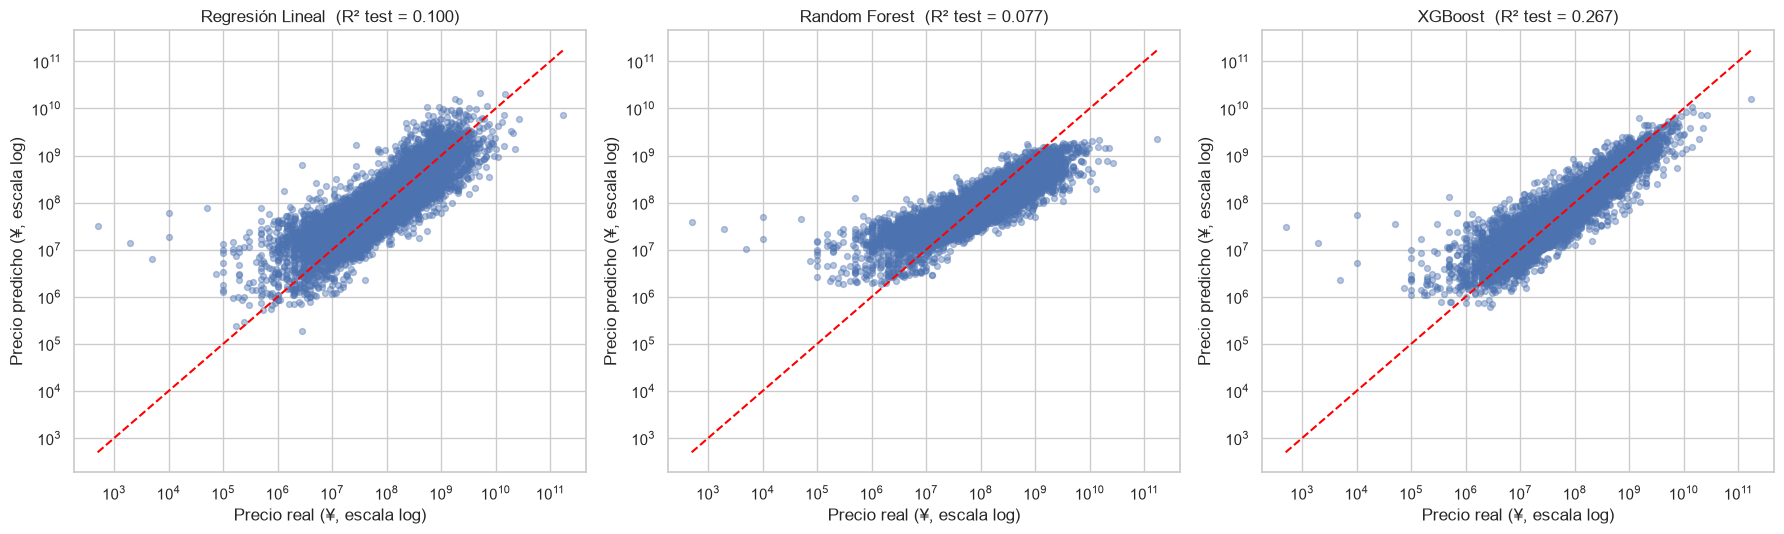

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
lim = [yreal_test.min(), yreal_test.max()]

for ax, (nombre, pred) in zip(axes, predicciones_test.items()):
    ax.scatter(yreal_test, pred, alpha=0.4, s=18, color="#4C72B0")
    ax.plot(lim, lim, "--", color="red", lw=1.5)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Precio real (¥, escala log)")
    ax.set_ylabel("Precio predicho (¥, escala log)")
    r2 = r2_score(yreal_test, pred)
    ax.set_title(f"{nombre}  (R² test = {r2:.3f})")

plt.tight_layout()
plt.show()


## 10. Selección del mejor modelo y análisis de residuos

Elegimos el mejor modelo por **menor RMSE en test** (métrica sensible a los errores grandes, relevante
por la cola de precios). En caso de empate técnico, prima el más simple/interpretable.


In [21]:
mejor_nombre = df_resultados.sort_values("RMSE_test").iloc[0]["Modelo"]
mejor_pipe = pipelines_entrenados[mejor_nombre]
pred_mejor = predicciones_test[mejor_nombre]
print("Mejor modelo por RMSE en test:", mejor_nombre)


Mejor modelo por RMSE en test: XGBoost


### 10.1 Análisis de residuos del mejor modelo

Trabajamos los residuos en **escala log** (donde se entrenó el modelo), que es donde tiene sentido
evaluar la homocedasticidad del ajuste.


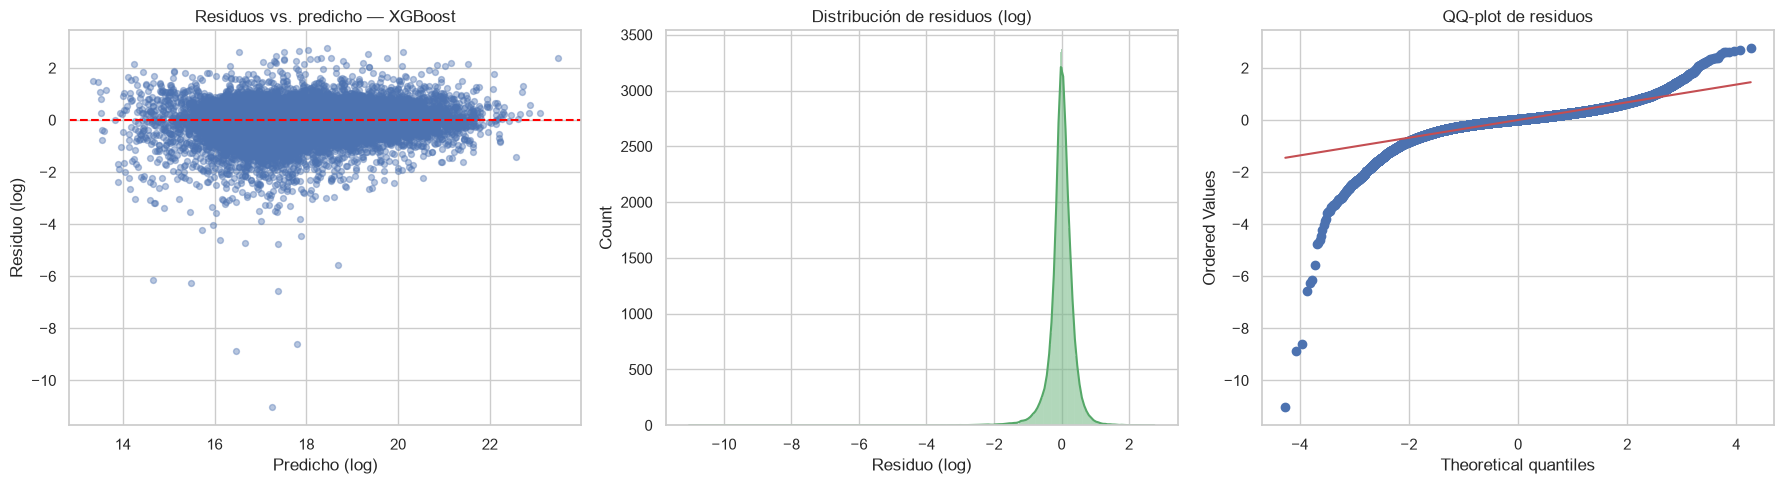

Media de residuos: 0.0010  (idealmente ≈ 0)
Desvío de residuos: 0.3693


In [22]:
y_pred_log_test = mejor_pipe.predict(X_test)
residuos_log = y_test - y_pred_log_test

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Residuos vs. predicho
axes[0].scatter(y_pred_log_test, residuos_log, alpha=0.4, s=18, color="#4C72B0")
axes[0].axhline(0, color="red", ls="--")
axes[0].set_xlabel("Predicho (log)"); axes[0].set_ylabel("Residuo (log)")
axes[0].set_title(f"Residuos vs. predicho — {mejor_nombre}")

# Distribución de residuos
sns.histplot(residuos_log, kde=True, ax=axes[1], color="#55A868")
axes[1].set_title("Distribución de residuos (log)")
axes[1].set_xlabel("Residuo (log)")

# QQ-plot
from scipy import stats
stats.probplot(residuos_log, dist="norm", plot=axes[2])
axes[2].set_title("QQ-plot de residuos")

plt.tight_layout()
plt.show()

print(f"Media de residuos: {residuos_log.mean():.4f}  (idealmente ≈ 0)")
print(f"Desvío de residuos: {residuos_log.std():.4f}")


### 11.1 Importancia de variables (si el mejor es árbol/boosting)
Extraemos `feature_importances_`, reconstruyendo los nombres tras el OneHot. Si el mejor fuera lineal,
se muestran los coeficientes de mayor magnitud.

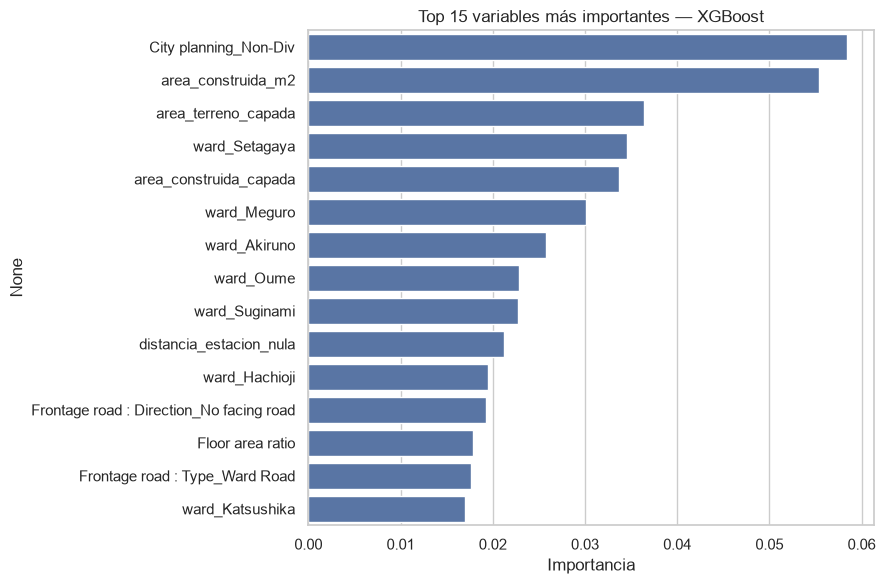

,importancia
City planning_Non-Div,0.058423
area_construida_m2,0.055377
area_terreno_capada,0.036432
ward_Setagaya,0.034603
area_construida_capada,0.033662
ward_Meguro,0.030134
ward_Akiruno,0.025812
ward_Oume,0.022877
ward_Suginami,0.022749
distancia_estacion_nula,0.021169


In [23]:
def nombres_features(pipe):
    prep = pipe.named_steps["prep"]
    nombres = list(cols_numericas)
    ohe = prep.named_transformers_["cat"].named_steps["onehot"]
    nombres += list(ohe.get_feature_names_out(cols_categoricas))
    return nombres

modelo_final = mejor_pipe.named_steps["model"]
if hasattr(modelo_final, "feature_importances_"):
    nombres = nombres_features(mejor_pipe)
    importancias = pd.Series(modelo_final.feature_importances_, index=nombres).sort_values(ascending=False)
    top = importancias.head(15)

    plt.figure(figsize=(9, 6))
    sns.barplot(x=top.values, y=top.index, color="#4C72B0")
    plt.title(f"Top 15 variables más importantes — {mejor_nombre}")
    plt.xlabel("Importancia")
    plt.tight_layout()
    plt.show()
    display(top.to_frame("importancia"))
else:
    # Modelo lineal: usar coeficientes
    print("El mejor modelo es lineal; se muestran los coeficientes de mayor magnitud.")
    coefs = pd.Series(modelo_final.coef_, index=nombres_features(mejor_pipe))
    print(coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(15))


### 11.2 Ajuste de hiperparámetros (búsqueda aleatoria sobre Random Forest)

Se emplea `RandomizedSearchCV` en lugar de una búsqueda exhaustiva, y **sobre una muestra** del conjunto
de entrenamiento. La razón es de costo: con ~275k filas y ~160 columnas tras el One-Hot, cada ajuste de
Random Forest cuesta varios minutos, de modo que una grilla completa resultaba inviable en el entorno
disponible. Buscar sobre una muestra preserva el ordenamiento relativo entre configuraciones, que es lo
que interesa para elegir hiperparámetros.

El modelo evaluado en test entrenó, por tanto, con menos datos que los de la sección 7: su desempeño
debe leerse como una **cota inferior**, no como una comparación directa contra el XGBoost ganador.

In [24]:
from sklearn.model_selection import RandomizedSearchCV

# ---------------------------------------------------------------------------------------------
# NOTA DE COSTO: con ~275k filas y ~150 columnas tras el One-Hot, un solo fit de Random Forest
# sobre el train completo cuesta decenas de minutos en CPU (scikit-learn no tiene soporte GPU).
# Por eso la búsqueda se hace enteramente sobre una MUESTRA y NO se reentrena sobre el total:
# el objetivo acá es comparar configuraciones entre sí, no producir el modelo final
# (ese ya se entrenó en la sección 7 y es el que se serializa para el TP4).
# ---------------------------------------------------------------------------------------------
N_MUESTRA = 50_000

idx = X_train.sample(n=min(N_MUESTRA, len(X_train)), random_state=RANDOM_STATE).index
X_busq = X_train.loc[idx]
y_busq = pd.Series(y_train, index=X_train.index).loc[idx]
print(f"Búsqueda sobre {len(X_busq):,} filas (de {len(X_train):,} del train)")

pipe_rf = Pipeline([("prep", preprocesador),
                    ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=2))])

espacio = {
    "model__n_estimators": [100],
    "model__max_depth": [12, 20],
    "model__min_samples_leaf": [5, 20],
}

grid = RandomizedSearchCV(pipe_rf, espacio, n_iter=4, cv=3, scoring="r2",
                          n_jobs=-1, random_state=RANDOM_STATE, verbose=2)
grid.fit(X_busq, y_busq)

print("\nMejores hiperparámetros:", grid.best_params_)
print(f"Mejor R² en CV (sobre la muestra): {grid.best_score_:.3f}")

# Evaluamos el mejor estimador de la búsqueda directamente en test, SIN reentrenar en el train
# completo. Es una cota inferior del desempeño (entrenó con menos datos), suficiente para
# concluir si el tuning aporta sobre la configuración de la sección 5.
pred_grid = a_escala_real(grid.predict(X_test))
m_grid = metricas_regresion(yreal_test, pred_grid,
                            grid.best_estimator_.named_steps["prep"].transform(X_busq).shape[1])
print(f"R² test (RF tuneado sobre muestra): {m_grid['R2']:.3f}  |  RMSE test: ¥{m_grid['RMSE']:,.0f}")
print("\nComparar contra el RF de la sección 7 (entrenado con el train completo) en la tabla final.")

Búsqueda sobre 50,000 filas (de 275,196 del train)
Fitting 3 folds for each of 4 candidates, totalling 12 fits

Mejores hiperparámetros: {'model__n_estimators': 100, 'model__min_samples_leaf': 5, 'model__max_depth': 20}
Mejor R² en CV (sobre la muestra): 0.758
R² test (RF tuneado sobre muestra): 0.140  |  RMSE test: ¥674,922,600

Comparar contra el RF de la sección 7 (entrenado con el train completo) en la tabla final.


### 11.3 Curva de aprendizaje (mejor modelo)

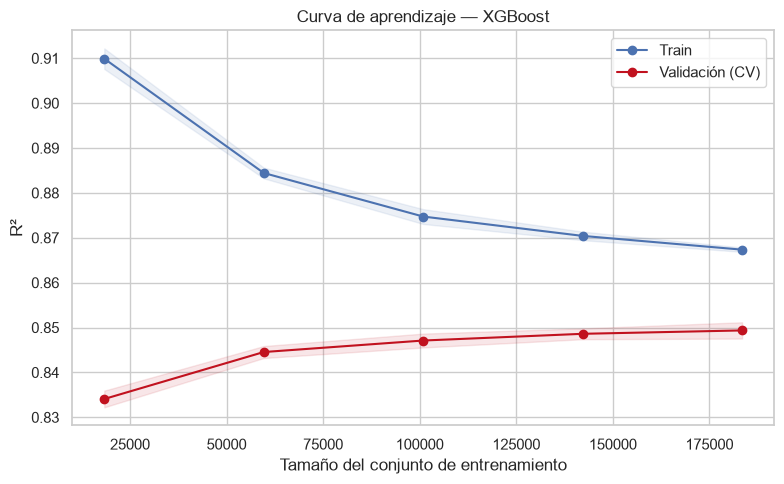

In [25]:
# La curva de aprendizaje reentrena el modelo en cada tamaño y fold: con 275k filas es costosa.
# Reducimos a 3 folds y 5 puntos, suficiente para leer la tendencia (sesgo vs. varianza).
train_sizes, train_scores, val_scores = learning_curve(
    mejor_pipe, X_train, y_train, cv=3, scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=1, random_state=RANDOM_STATE)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), "o-", label="Train", color="#4C72B0")
plt.plot(train_sizes, val_scores.mean(axis=1), "o-", label="Validación (CV)", color="#c1121f")
plt.fill_between(train_sizes, train_scores.mean(1)-train_scores.std(1),
                 train_scores.mean(1)+train_scores.std(1), alpha=0.1, color="#4C72B0")
plt.fill_between(train_sizes, val_scores.mean(1)-val_scores.std(1),
                 val_scores.mean(1)+val_scores.std(1), alpha=0.1, color="#c1121f")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("R²")
plt.title(f"Curva de aprendizaje — {mejor_nombre}")
plt.legend()
plt.tight_layout()
plt.show()

### 11.4 Pipeline integrado serializado (insumo para el TP4)

Guardamos el mejor modelo como un `Pipeline` único (preprocesamiento + modelo) con `joblib`. Este
artefacto es el candidato a desplegarse en la app del TP4: recibe un registro crudo y devuelve el
precio estimado.


In [26]:
import joblib

# Reentrenamos el mejor pipeline sobre TODO el dataset (train+test) para el artefacto de despliegue.
pipe_deploy = Pipeline([("prep", preprocesador), ("model", modelos[mejor_nombre])])
pipe_deploy.fit(X, y)   # y está en escala log1p

artefacto = {
    "pipeline": pipe_deploy,
    "target": TARGET,
    "target_transform": "log1p",           # aplicar np.expm1 a la salida para obtener ¥
    "cols_numericas": cols_numericas,
    "cols_categoricas": cols_categoricas,
    "modelo": mejor_nombre,
}
ruta = f"{MODEL_DIR}/tp2_mejor_regresor.joblib"
joblib.dump(artefacto, ruta)
print("Modelo serializado en:", ruta)

# Prueba rápida de carga y predicción
cargado = joblib.load(ruta)
ejemplo = X.iloc[[0]]
pred_ejemplo = np.expm1(cargado["pipeline"].predict(ejemplo))[0]
print(f"Predicción de ejemplo (fila 0): ¥{pred_ejemplo:,.0f}  |  real: ¥{y_real[0]:,.0f}")


Modelo serializado en: outputs/models/tp2_mejor_regresor.joblib
Predicción de ejemplo (fila 0): ¥146,343,616  |  real: ¥340,000,000


## 12. Cuestionario de Interpretación de Resultados

**1. ¿Cuál resultó el mejor modelo y por qué? ¿Cambiaría al priorizar otra métrica?**

La celda siguiente calcula el ranking según cada métrica:

In [27]:
ranking = df_resultados.set_index("Modelo")[["R2log_test", "R2_test", "RMSE_test", "MAE_test", "MAPE_test"]].copy()
print("Mejor por R²(log) (↑):", ranking["R2log_test"].idxmax())
print("Mejor por R²(¥) (↑):  ", ranking["R2_test"].idxmax())
print("Mejor por RMSE (↓):   ", ranking["RMSE_test"].idxmin())
print("Mejor por MAE (↓):    ", ranking["MAE_test"].idxmin())
print("Mejor por MAPE (↓):   ", ranking["MAPE_test"].idxmin())
ranking.round(3)


Mejor por R²(log) (↑): XGBoost
Mejor por R²(¥) (↑):   XGBoost
Mejor por RMSE (↓):    XGBoost
Mejor por MAE (↓):     XGBoost
Mejor por MAPE (↓):    XGBoost


,R2log_test,R2_test,RMSE_test,MAE_test,MAPE_test
Modelo,,,,,
Regresión Lineal,0.724,0.100,6.904252e+08,4.718215e+07,164.334
Random Forest,0.705,0.077,6.991237e+08,4.322568e+07,195.864
XGBoost,0.848,0.267,6.229502e+08,2.949087e+07,140.073


El dataset de toda la prefectura de Tokio es **grande (~340k filas), tabular y heterogéneo**, con
relaciones fuertemente no lineales (el precio salta con la superficie y sobre todo con el ward) y una
cola de outliers legítima (edificios corporativos en los wards céntricos) → favorece árboles/boosting
sobre el lineal. En los residuos (10.1): si la nube se abre en los precios altos hay
**heterocedasticidad** — parte la absorbe `log1p`, pero el remanente indica más incertidumbre en las
operaciones grandes (pocas y variables). El QQ-plot muestra si las colas se desvían de la normal.
Patrones no capturados: atributos ausentes del dataset (calidad edilicia, estado de conservación,
condiciones de cada operación) que ningún modelo puede inferir de las columnas disponibles.

## 13. Conclusiones y cierre
- Se compararon tres regresores (baseline lineal + dos ensambles) bajo marco controlado (hold-out 80/20 +
  CV 5-fold, semilla fija), evaluando en ¥ con RMSE, MAE, R², R² ajustado y MAPE.
- Modelar en `log1p` fue clave por la asimetría del precio detectada en el TP1.
- El mejor modelo se serializó como `Pipeline` único (`outputs/models/tp2_mejor_regresor.joblib`),
  candidato de despliegue para el **TP4**.
- Importancia de variables, residuos y curva de aprendizaje alimentan el paper IEEE del TP4.